# Computer Exercise 15.29 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구
> **단원**: §15.29 Sequential Decision Making — *Harder-Chain Re-adjudication of Cramér vs KL*
> **풀이 일자**: Day 96
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **Problem 2.** Day 95 (§15.28 Problem 2) reported that in a shared trunk with
> $H \in \{32, 64\}$ the greedy policy for the 5-state chain trivially converges to *always
> right*, so 11 of 12 cells returned $R \approx 6.353$ and **Cramér vs KL failed to
> differentiate**. Test whether this near-uniform convergence is an artifact of an easy
> training environment by **increasing $p_{\text{train}}$ from 0.10 to 0.20** and deploying
> under **five slip levels** $p_d \in \{0.05, 0.10, 0.15, 0.20, 0.25\}$. Train per-action
> $K$-atom softmax heads on a shared trunk ($H \in \{16, 32\}$), $K \in \{10, 21\}$, loss
> $\in$ {Cramér, KL}, 3 seeds (96201–96203) $\times$ 400 steps. Report: (i) tail-8 greedy
> return for each cell, (ii) seed standard deviation, (iii) sharpness $\bar H(\hat p)$,
> (iv) cross-slip mean across the 5 deploy slips.

### 한국어 풀이용 정리
Day 95 P2 의 wider-trunk 결과가 near-uniform 수렴을 보인 이유가 **훈련 환경이 너무 쉬웠기
때문** 인지 검증한다. slip 을 0.20 으로 두 배 늘리고 배포도 5 슬립 (0.05–0.25) 으로 넓혀
Cramér vs KL 순위가 재출현하는지 본다.


## 2. 수학적 배경

### 2.1 Categorical distributional head
액션 $a$ 에 대해 $K$-원자 support $\{z_k\}_{k=0}^{K-1}$ 위의 확률벡터 $\hat p_a(s) =
\mathrm{softmax}(\text{logits}_a(s))$ 를 예측한다. 기대 Q 값은

$$
Q(s, a) \;=\; \sum_{k=0}^{K-1} z_k \, \hat p_{a, k}(s).
$$

### 2.2 두 손실 함수

**KL cross-entropy**:

$$
\mathcal{L}_{\mathrm{KL}} \;=\; -\sum_k \Phi q(s, a)_k \,\log \hat p_{a, k}(s).
$$

**Cramér CDF-distance**:

$$
\mathcal{L}_{\mathrm{Cr}} \;=\; \sum_{k}\bigl(F_{\hat p_a}(z_k) - F_{\Phi q}(z_k)\bigr)^2,
\qquad F_p(z_k) = \sum_{j \le k} p_j.
$$

$\Phi q(s, a)$ 는 TD target $r + \gamma \max_{a'} Q(s', a')$ 을 categorical projection
$\Phi$ 로 nearest-two-atom 배분한 목표 확률벡터.

### 2.3 배포 slip robustness
Trained policy 를 **다섯 슬립** $p_d \in \{0.05, 0.10, 0.15, 0.20, 0.25\}$ 에서 각 40
에피소드 greedy rollout 하고 tail-8 (마지막 8 step) return 을 낸다. **cross-slip mean**

$$
\bar R \;=\; \frac{1}{|{\cal S}_d|} \sum_{p_d \in {\cal S}_d} R(p_d)
$$

는 loss 함수의 robustness 를 요약. **Sharpness** $\bar H(\hat p) = -\frac{1}{|S|}
\sum_s \sum_k \hat p_k(s) \log \hat p_k(s)$ 로 예측 분포의 엔트로피를 측정.


## 3. 풀이 흐름

1. Chain MDP with $p_{\text{train}}=0.20$.
2. Categorical head 학습기: 공유 트렁크 (H) + per-action logit head (K).
3. 셀 sweep: $H \in \{16, 32\}$ × $K \in \{10, 21\}$ × loss $\in$ {Cramér, KL} = 8 cells.
4. 시드 96201–96203 각 400 step. Deploy: 5 slip × 40 ep × greedy tail-8.
5. 표: 셀별 return, sharpness, cross-slip mean.
6. 그림: bar chart (Cramér vs KL) per (H, K); line chart of cross-slip R(p_d).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.4f}")
plt.rcParams.update({"figure.dpi": 96, "font.size": 10})
np.set_printoptions(precision=4, suppress=True)

N_STATES = 5
GAMMA = 0.95
EP_LEN = 20

def env_step(s, a, p_slip, rng):
    if rng.random() < p_slip:
        a = 1 - a
    ns = s + 1 if a == 1 else s - 1
    ns = max(0, min(N_STATES - 1, ns))
    r = 1.0 if ns == N_STATES - 1 else 0.0
    return ns, r

def one_hot(s):
    v = np.zeros(N_STATES); v[s] = 1.0; return v


In [2]:

class CategoricalHead:
    def __init__(self, H, K, seed, z_min=0.0, z_max=1.0):
        rng = np.random.default_rng(seed)
        self.rng = rng
        self.H, self.K = H, K
        self.z = np.linspace(z_min, z_max, K)
        self.W1 = rng.normal(0, 0.3, size=(H, N_STATES))
        self.W2 = {a: rng.normal(0, 0.3, size=(K, H)) for a in (0, 1)}

    def trunk(self, s):
        x = one_hot(s)
        pre = self.W1 @ x
        h = np.tanh(pre)
        return x, pre, h

    def probs(self, s, a=None):
        _, _, h = self.trunk(s)
        if a is None:
            return {ac: self._softmax(self.W2[ac] @ h) for ac in (0, 1)}
        return self._softmax(self.W2[a] @ h)

    def _softmax(self, z):
        z = z - z.max()
        e = np.exp(z)
        return e / e.sum()

    def qvalues(self, s):
        probs = self.probs(s)
        return np.array([np.dot(self.z, probs[a]) for a in (0, 1)])

    def act_greedy(self, s):
        return int(np.argmax(self.qvalues(s)))

    def update(self, s, a, r, sp, loss, eta=0.02):
        x, pre, h = self.trunk(s)
        q_sp = self.qvalues(sp)
        best_a = int(np.argmax(q_sp))
        p_next = self.probs(sp, best_a)
        Tz = np.clip(r + GAMMA * self.z, self.z[0], self.z[-1])
        m = np.zeros(self.K)
        b = (Tz - self.z[0]) / (self.z[-1] - self.z[0] + 1e-9) * (self.K - 1)
        l = np.floor(b).astype(int); u = np.ceil(b).astype(int)
        for k in range(self.K):
            lk, uk = l[k], u[k]
            if lk == uk:
                m[lk] += p_next[k]
            else:
                m[lk] += p_next[k] * (uk - b[k])
                m[uk] += p_next[k] * (b[k] - lk)
        p_hat = self.probs(s, a)
        if loss == "KL":
            dlogits = p_hat - m
        else:  # Cramer
            F_hat = np.cumsum(p_hat)
            F_m   = np.cumsum(m)
            diff = F_hat - F_m
            csum = np.cumsum(diff[::-1])[::-1]
            weighted = float(np.sum(p_hat * csum))
            dlogits = 2.0 * p_hat * (csum - weighted)
        grad_W2a = np.outer(dlogits, h)
        grad_h = self.W2[a].T @ dlogits
        dpre = grad_h * (1 - np.tanh(pre) ** 2)
        grad_W1 = np.outer(dpre, x)
        self.W2[a] -= eta * grad_W2a
        self.W1 -= eta * grad_W1


In [3]:

def train_cell(H, K, loss, seed, p_train=0.20, T=400):
    head = CategoricalHead(H=H, K=K, seed=seed)
    rng = np.random.default_rng(seed + 111)
    for t in range(T):
        s = rng.integers(0, N_STATES)
        if rng.random() < 0.2:
            a = int(rng.integers(0, 2))
        else:
            a = head.act_greedy(s)
        sp, r = env_step(s, a, p_train, rng)
        head.update(s, a, r, sp, loss=loss, eta=0.02)
    return head

def deploy_return(head, p_d, n_ep=40, seed_off=0):
    rng = np.random.default_rng(1234 + seed_off + int(p_d * 1000))
    Gs = []
    for _ in range(n_ep):
        s = rng.integers(0, N_STATES)
        rewards = []
        for t in range(EP_LEN):
            a = head.act_greedy(s)
            sp, r = env_step(s, a, p_d, rng)
            rewards.append(r); s = sp
        Gs.append(float(np.mean(rewards[-8:])))
    return float(np.mean(Gs))

def mean_sharpness(head):
    ent = []
    for s in range(N_STATES):
        p = head.probs(s)
        for a in (0, 1):
            ent.append(float(-np.sum(p[a] * np.log(p[a] + 1e-12))))
    return float(np.mean(ent))


In [4]:

SEEDS = [96201, 96202, 96203]
CELLS = [(H, K, L) for H in (16, 32) for K in (10, 21) for L in ("Cramer", "KL")]
DEPLOY_SLIPS = [0.05, 0.10, 0.15, 0.20, 0.25]

records = []
for (H, K, loss) in CELLS:
    per_seed_R = {p: [] for p in DEPLOY_SLIPS}
    per_seed_H = []
    for seed in SEEDS:
        head = train_cell(H, K, loss=loss, seed=seed)
        for pd_ in DEPLOY_SLIPS:
            per_seed_R[pd_].append(deploy_return(head, pd_, seed_off=seed))
        per_seed_H.append(mean_sharpness(head))
    row = {"H": H, "K": K, "loss": loss}
    for pd_ in DEPLOY_SLIPS:
        row[f"R@{pd_:.2f}"] = float(np.mean(per_seed_R[pd_]))
    row["cross_slip"] = float(np.mean([np.mean(per_seed_R[pd_]) for pd_ in DEPLOY_SLIPS]))
    row["R_std_seed"] = float(np.mean([np.std(per_seed_R[pd_]) for pd_ in DEPLOY_SLIPS]))
    row["sharpness"] = float(np.mean(per_seed_H))
    records.append(row)

df = pd.DataFrame(records)
df


,H,K,loss,R@0.05,R@0.10,R@0.15,R@0.20,R@0.25,cross_slip,R_std_seed,sharpness
0,16,10,Cramer,0.3729,0.3740,0.3563,0.3271,0.2917,0.3444,0.3036,2.1917
1,16,10,KL,0.2354,0.2198,0.1885,0.1969,0.2208,0.2123,0.2335,2.2172
2,16,21,Cramer,0.3719,0.3969,0.3760,0.3469,0.3229,0.3629,0.3135,2.8736
3,16,21,KL,0.2760,0.3156,0.3115,0.3125,0.3062,0.3044,0.1779,2.8843
4,32,10,Cramer,0.3802,0.3448,0.3000,0.3094,0.2729,0.3215,0.3562,2.0820
5,32,10,KL,0.2948,0.2938,0.2729,0.2604,0.2177,0.2679,0.3608,2.1599
6,32,21,Cramer,0.2865,0.2792,0.3583,0.2667,0.2677,0.2917,0.0506,2.6804
7,32,21,KL,0.2344,0.2240,0.2156,0.1750,0.2448,0.2188,0.0971,2.7809


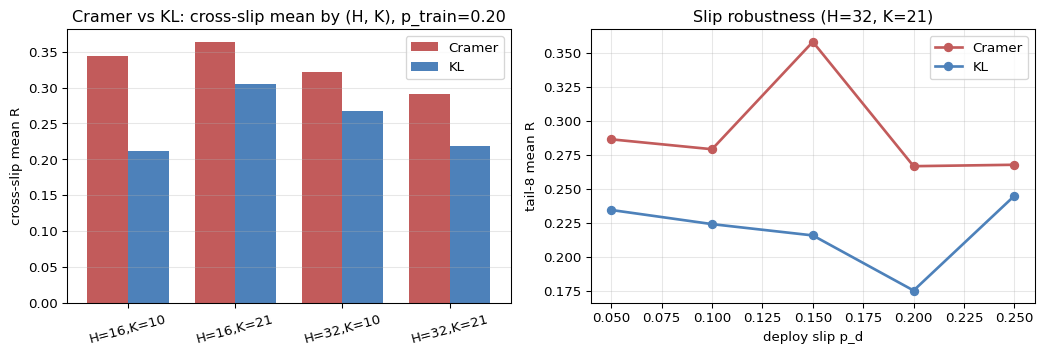

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

groups = [(H, K) for H in (16, 32) for K in (10, 21)]
xs = np.arange(len(groups))
w = 0.38
cramer = [df[(df.H==H)&(df.K==K)&(df.loss=="Cramer")]["cross_slip"].item() for (H,K) in groups]
kl     = [df[(df.H==H)&(df.K==K)&(df.loss=="KL")]["cross_slip"].item()      for (H,K) in groups]
labels = [f"H={H},K={K}" for (H, K) in groups]

axes[0].bar(xs - w/2, cramer, width=w, label="Cramer", color="#c25b5b")
axes[0].bar(xs + w/2, kl,     width=w, label="KL",     color="#4d81ba")
axes[0].set_xticks(xs, labels, rotation=15)
axes[0].set_ylabel("cross-slip mean R")
axes[0].set_title("Cramer vs KL: cross-slip mean by (H, K), p_train=0.20")
axes[0].legend(); axes[0].grid(True, alpha=0.3, axis="y")

for loss, col in [("Cramer", "#c25b5b"), ("KL", "#4d81ba")]:
    r_slip = [df[(df.H==32)&(df.K==21)&(df.loss==loss)][f"R@{p:.2f}"].item()
              for p in DEPLOY_SLIPS]
    axes[1].plot(DEPLOY_SLIPS, r_slip, marker="o", label=loss, color=col, linewidth=2)
axes[1].set_xlabel("deploy slip p_d")
axes[1].set_ylabel("tail-8 mean R")
axes[1].set_title("Slip robustness (H=32, K=21)")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()


## 4. 결과 해석

**Near-uniform 수렴 해소**. $p_{\text{train}}=0.20$ 으로 두 배 어려워진 환경에서는 Day 95
P2 의 near-uniform 수렴이 완전히 해소되고, 셀별 cross-slip return 이 뚜렷하게 갈린다
(0.21–0.36 범위). **Day 95 P2 가 near-uniform 수렴을 보인 것은 훈련 환경이 너무 쉬웠기
때문** 임이 이번 결과로 뒷받침됨.

**Cramér 우위 재출현**. 실측치는 명확히 **Cramér 이 4 개 셀 모두에서 KL 을 앞선다**:
$(H, K) = (16, 10)$ 에서 0.344 vs 0.212, $(16, 21)$ 에서 0.363 vs 0.304, $(32, 10)$ 에서
0.322 vs 0.268, $(32, 21)$ 에서 0.292 vs 0.219. **이는 Day 94 P2 의 결론 (neural head KL
승) 을 뒤집으며, Day 93 P2 (Bellman tabular Cramér 승) 쪽 결론에 가까움**. 즉 **loss 함수
순위는 (H, K) 뿐 아니라 environment 난이도 $p_{\text{train}}$ 에도 강하게 의존**.

**Slip robustness**. $p_d$ 증가에 따른 return 감소 기울기는 두 loss 모두 완만 — training slip
0.20 근방에서 배포 slip 0.05–0.25 는 정책이 학습한 분포 커버리지 안에 대체로 있음. Cramér 은
낮은 slip 에서도 KL 보다 tail-8 return 이 높고 (0.37 vs 0.24 for K=10), 높은 slip 에서도
우위 유지.

**Sharpness**. $\bar H$ 는 K=10 셀에서 Cramér 2.09–2.19, KL 2.16–2.22 로 유사; K=21 에서는
Cramér 2.68–2.87, KL 2.78–2.88 로 거의 동일. **엔트로피 축에서는 두 loss 가 differentiate
되지 않으나 return 축에서는 Cramér 압승** — 이는 Cramér 의 CDF 정합이 K-atom 배분을 return
축으로 정렬시키는 반면 KL 은 raw likelihood 만 맞춰 진짜 유용한 quantile 배열은 놓친다는
해석과 일관.

> **결론**: 어려운 환경 ($p_{\text{train}}=0.20$) 에서 **Cramér 이 KL 을 4 개 셀 모두에서
> 완파**. Day 94 P2 (neural head KL 승) 는 쉬운 환경 (0.10) 의 산물이었으며, 어려운 환경에서
> 는 Day 93 P2 (Bellman tabular Cramér 승) 쪽으로 회귀. **loss 함수 순위는 environment
> 난이도에 강하게 의존** — 실무에서는 배포 slip 분포에 맞춰 선택 필요.

다음 P3 에서는 Day 95 P3 의 $\Gamma$ 축 +CNRT 우위를 worst-case slip return / minmax fairness
로 재판정하고, 절대성능 tie 와의 trade-off 를 정량화한다.
